In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report

In [90]:
df = sns.load_dataset("titanic")

In [91]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [92]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [93]:
df.drop("deck",axis = 1,inplace=True)

In [94]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [95]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [96]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [97]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [98]:
categorical = df.select_dtypes(include=["object","category"]).columns.tolist()
numerical = df.select_dtypes(include=["float64","int64"]).columns.tolist()
numerical

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

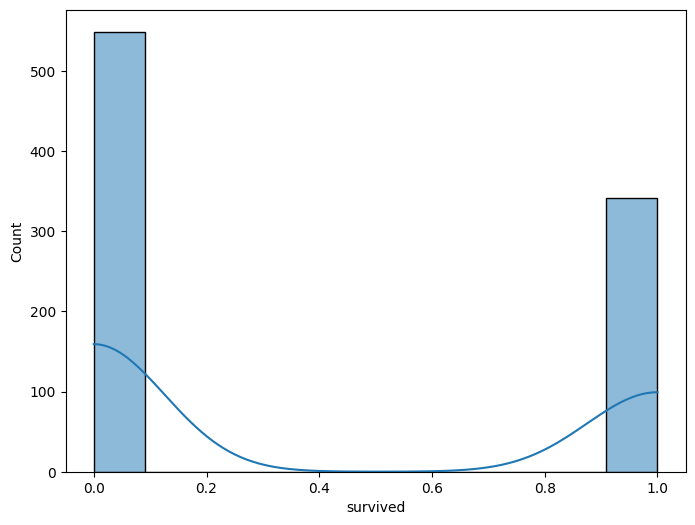

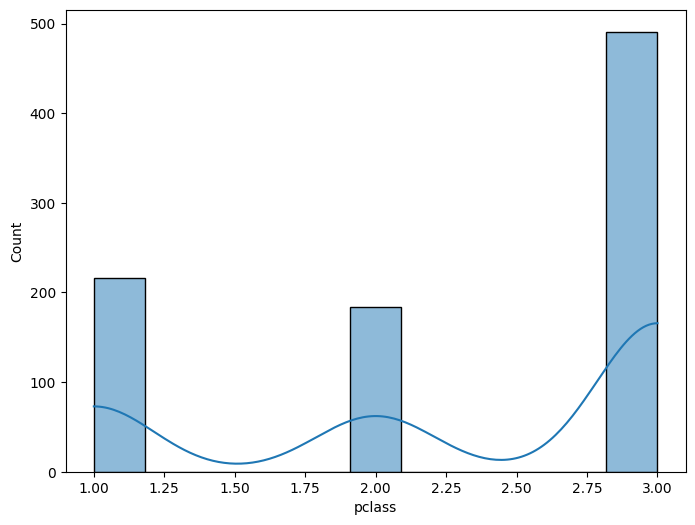

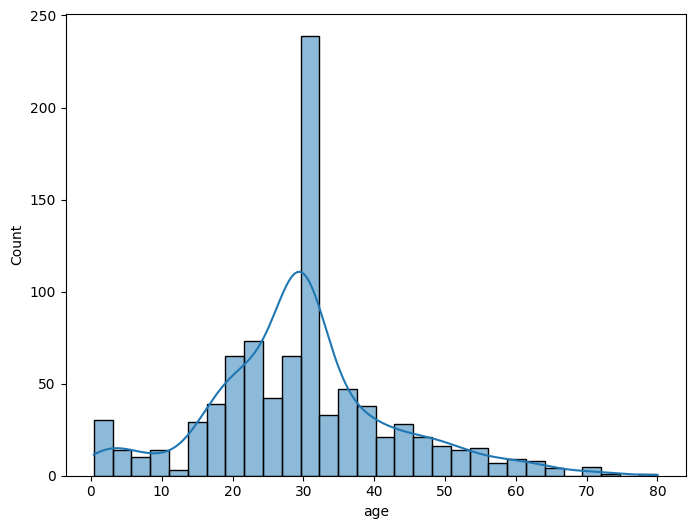

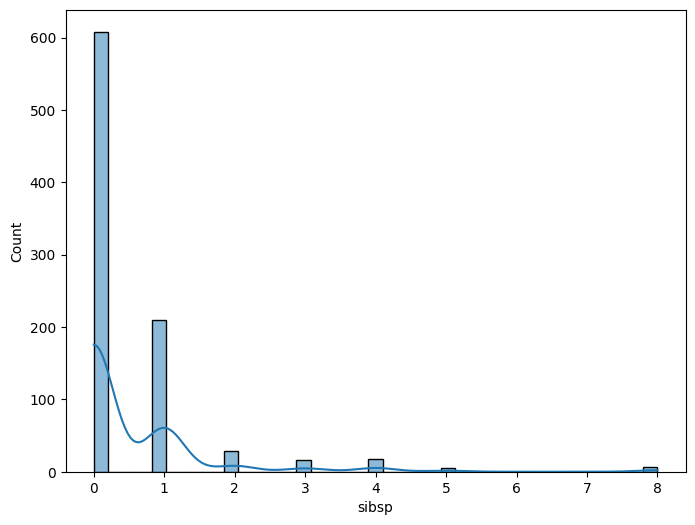

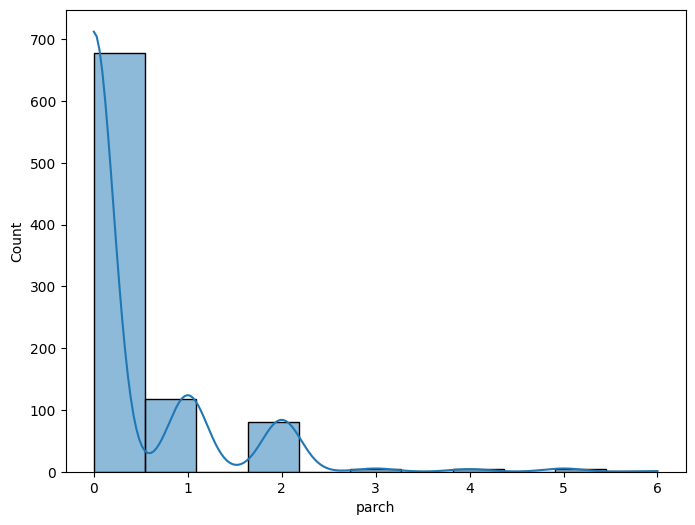

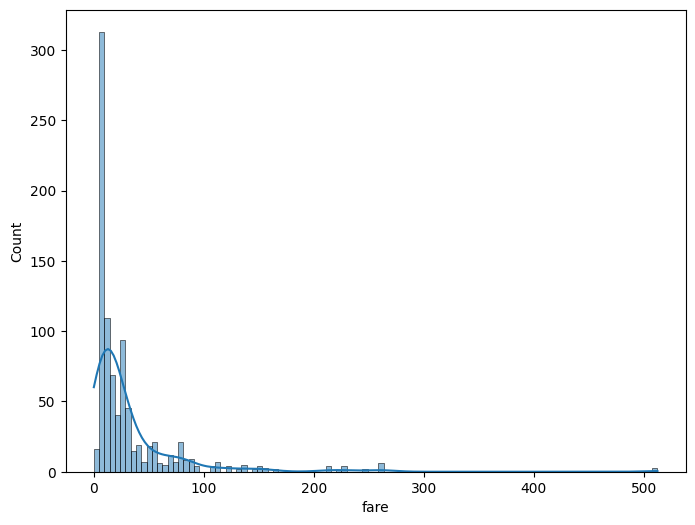

In [99]:
for col in numerical:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde = True)

In [100]:
u = df["parch"].unique().tolist()
unique_path = {}

for val in u:
    unique_path[val] = int((df["parch"] == val).sum())

unique_path

{0: 678, 1: 118, 2: 80, 5: 5, 3: 5, 4: 4, 6: 1}

In [101]:
outlier = ['survived', 'pclass', 'age', 'sibsp','fare']

In [102]:
for col in outlier:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)]

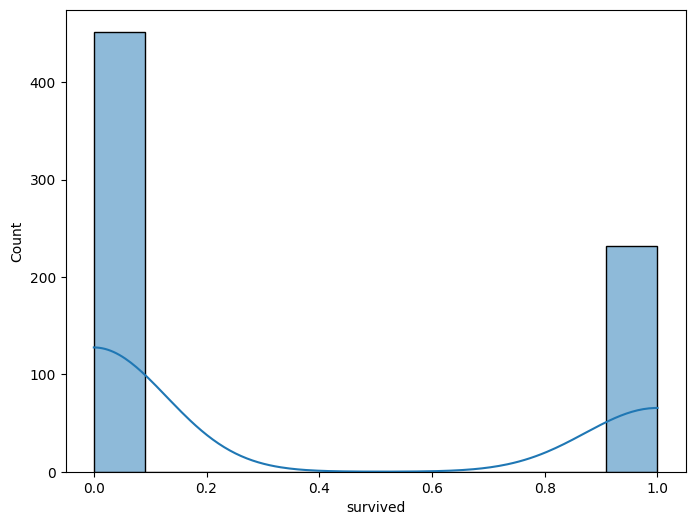

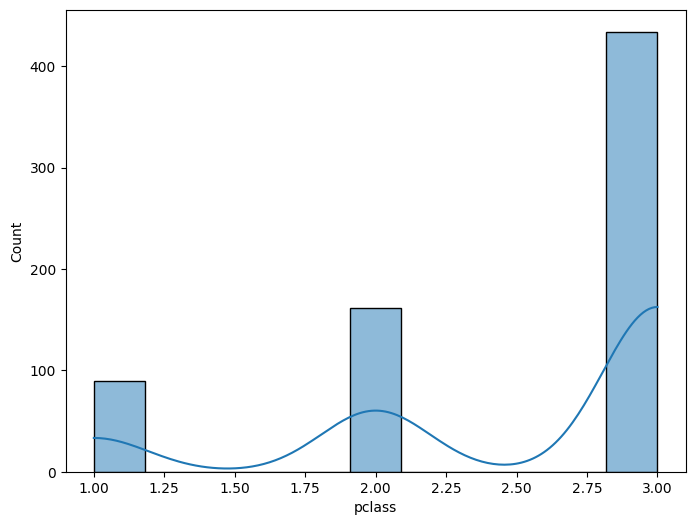

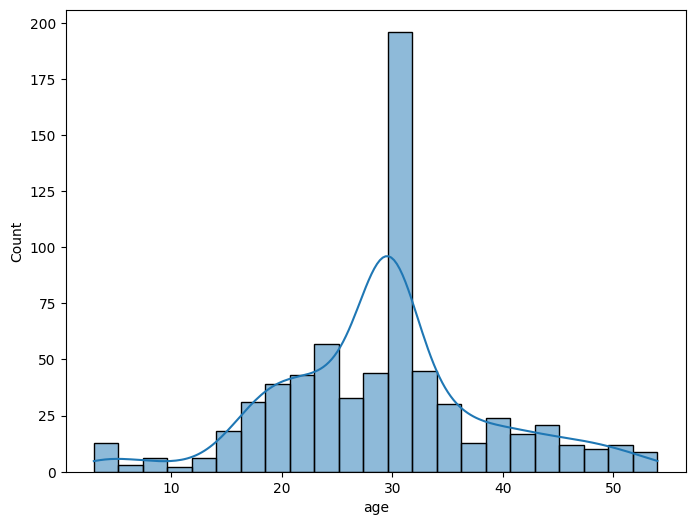

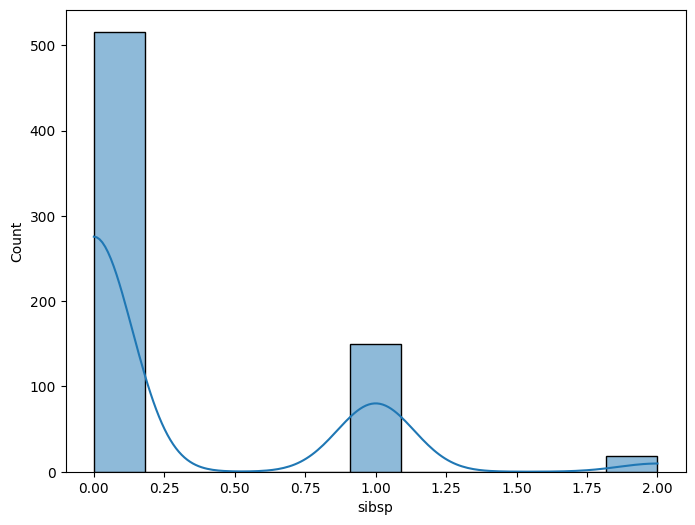

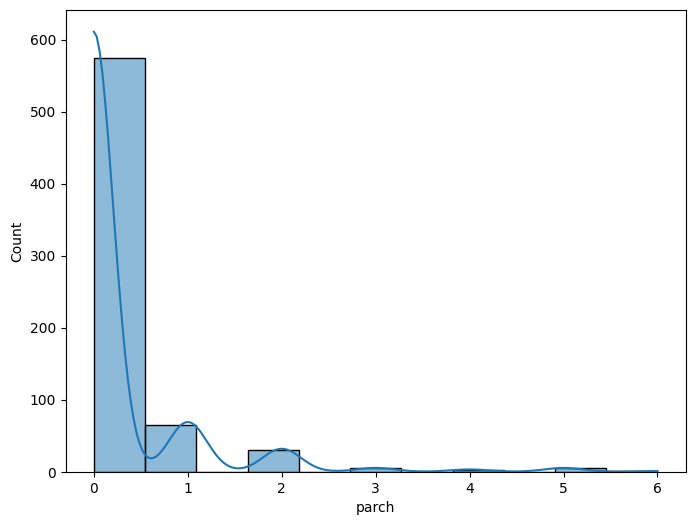

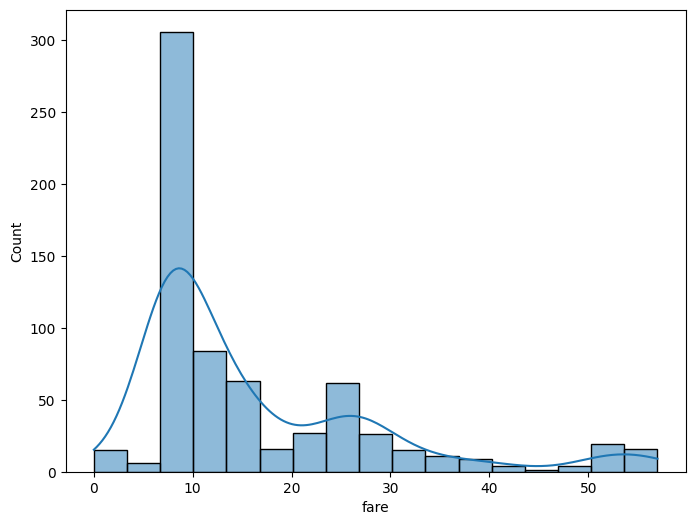

In [103]:
for col in numerical:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde = True)

In [104]:
df["parch"] = df["parch"].apply(lambda x: x if x <= 3 else 4)

<Axes: xlabel='parch', ylabel='Count'>

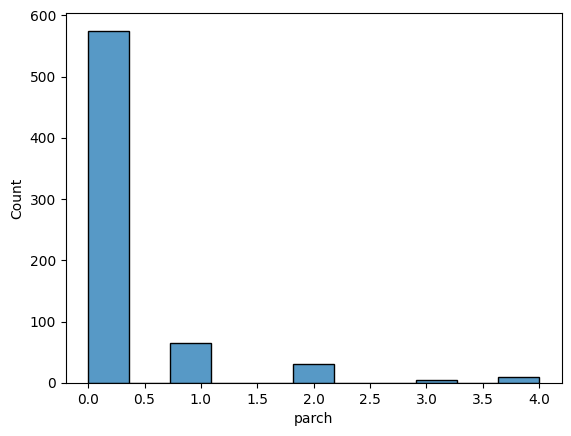

In [105]:
sns.histplot(df["parch"])

In [106]:
df.duplicated().sum()

np.int64(101)

In [107]:
df.drop_duplicates(inplace=True)

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,Queenstown,no,True


In [110]:
df[categorical].nunique()

,0
sex,2
embarked,3
class,3
who,3
embark_town,3
alive,2


In [111]:
hot_en = [col for col in categorical if df[col].nunique() > 2]
label_en = [col for col in categorical if df[col].nunique() == 2]

In [112]:
le = LabelEncoder()

In [113]:
for col in label_en:
  df[col] = le.fit_transform(df[col])

In [114]:
ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

In [115]:
encoded = ohe.fit_transform(df[hot_en])

In [116]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(hot_en),
    index=df.index
)

In [117]:
df = df.drop(columns=hot_en)
df = pd.concat([df, encoded_df], axis=1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,...,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,3,1,22.000000,1,0,7.2500,True,0,False,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1,3,0,26.000000,0,0,7.9250,False,1,True,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0,35.000000,1,0,53.1000,False,1,False,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,1,35.000000,0,0,8.0500,True,0,True,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0,3,1,29.699118,0,0,8.4583,True,0,True,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [118]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,...,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,0,3,1,22.000000,1,0,7.2500,True,0,False,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1,3,0,26.000000,0,0,7.9250,False,1,True,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0,35.000000,1,0,53.1000,False,1,False,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,1,35.000000,0,0,8.0500,True,0,True,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
5,0,3,1,29.699118,0,0,8.4583,True,0,True,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [119]:
X = df.drop("survived",axis=1)
y = df["survived"].fillna(0).astype("int")

In [120]:
scaler = StandardScaler()

In [121]:
for col in X.columns:
  X[col] = scaler.fit_transform(X[[col]])

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [123]:
dt_model = DecisionTreeClassifier()

In [124]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier()

In [125]:
y_pred = dt_model.predict(X_test)

In [126]:
print(f"DecisionTree Classification Report: \n",classification_report(y_test,y_pred))

DecisionTree Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        71

    accuracy                           1.00       193
   macro avg       1.00      1.00      1.00       193
weighted avg       1.00      1.00      1.00       193



In [127]:
lr_model = LogisticRegression(random_state=42)

In [128]:
lr_model.fit(X_train,y_train)

LogisticRegression(random_state=42)

In [129]:
y_pred = lr_model.predict(X_test)

In [130]:
print(f"LogisticRegression Classification Report: \n",classification_report(y_test,y_pred))

LogisticRegression Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        71

    accuracy                           1.00       193
   macro avg       1.00      1.00      1.00       193
weighted avg       1.00      1.00      1.00       193

